In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv('../data/raw/results.csv')
print("======shape=======")
print(df.shape)

print("\n=== Columns ===")
print(df.columns.tolist())

print("\n=== First 5 rows ===")
print(df.head())

print("\n=== Data types and null counts ===")
df.info()

print("\n=== Number statistics ===")
print(df.describe())



======shape=======
(49477, 9)

=== Columns ===
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

=== First 5 rows ===
         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   
3  1875-03-06   England  Scotland         2.0         2.0   Friendly   London   
4  1876-03-04  Scotland   England         3.0         0.0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  

=== Data types and null counts ===
<class 'pandas.DataFrame'>
RangeIndex: 49477 entries, 0 to 49476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------

In [7]:
# ---- Explore tournaments ----
print("\n=== Unique tournaments ===")
print(df["tournament"].nunique())

print("\n=== Top 10 tournaments by match count ===")
print(df["tournament"].value_counts().head(10))

wc = df[df["tournament"] == "FIFA World Cup"]
print(f"\nFIFA World Cup matches: {len(wc)}")


=== Unique tournaments ===
200

=== Top 10 tournaments by match count ===
tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
Name: count, dtype: int64

FIFA World Cup matches: 1036


In [8]:
# ---- Explore teams ----
print("\n=== Top 10 home teams by number of matches ===")
print(df["home_team"].value_counts().head(10))

print("\n=== Total unique teams ===")
all_teams = pd.concat([df["home_team"], df["away_team"]]).unique()
print(len(all_teams))



=== Top 10 home teams by number of matches ===
home_team
Brazil           616
Argentina        608
Mexico           605
Germany          556
England          552
South Korea      552
France           540
Sweden           535
United States    502
Hungary          499
Name: count, dtype: int64

=== Total unique teams ===
336


In [7]:
# ---- Explore dates ----
df["date"] = pd.to_datetime(df["date"])
print("\n=== Date range ===")
print(df["date"].min(), "to", df["date"].max())


=== Date range ===
1872-11-30 00:00:00 to 2026-06-27 00:00:00


In [8]:
# ---- Explore goals ----
print("\n=== Average goals per match ===")
print(f"Home: {df['home_score'].mean():.2f}")
print(f"Away: {df['away_score'].mean():.2f}")

print("\n=== Draw percentage ===")
draws = df[df["home_score"] == df["away_score"]]
print(f"{len(draws)/len(df):.1%} of all matches are draws")

print("\n=== Neutral venue matches ===")
print(df["neutral"].value_counts())


# ---- Check for missing values ----
print("\n=== Missing values per column ===")
print(df.isnull().sum())


=== Average goals per match ===
Home: 1.76
Away: 1.18

=== Draw percentage ===
22.7% of all matches are draws

=== Neutral venue matches ===
neutral
False    36356
True     13121
Name: count, dtype: int64

=== Missing values per column ===
date           0
home_team      0
away_team      0
home_score    44
away_score    44
tournament     0
city           0
country        0
neutral        0
dtype: int64


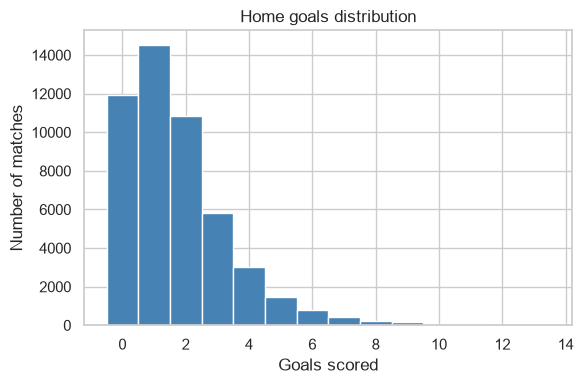

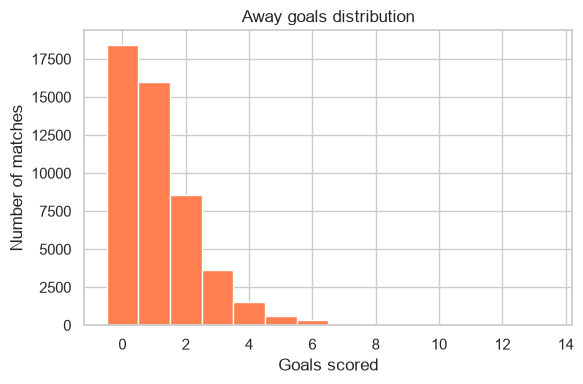

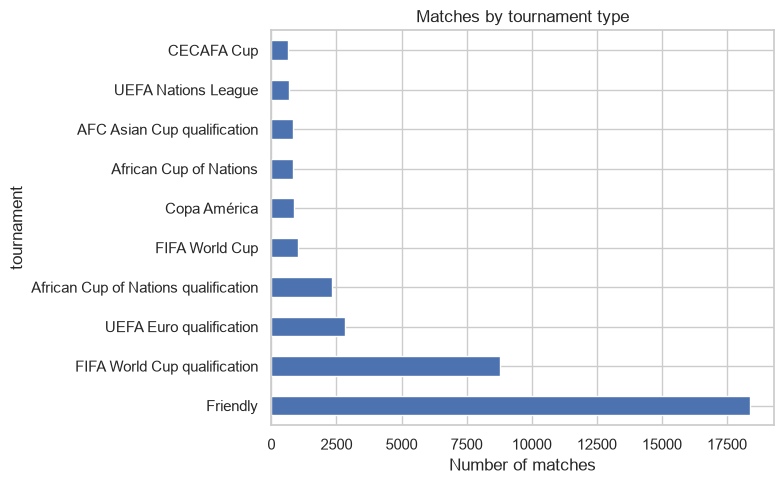

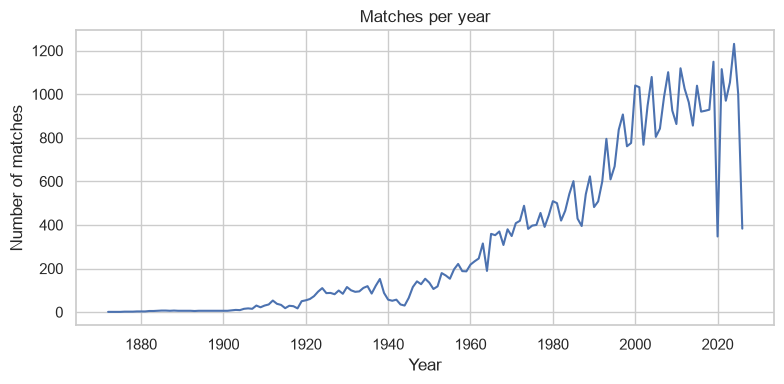

In [9]:

# ---- Visualizations ----
# Home goals distribution
plt.figure(figsize=(6, 4))
plt.hist(
    df["home_score"],
    bins=range(0, 15),
    color="steelblue",
    edgecolor="white",
    align="left"
)
plt.title("Home goals distribution")
plt.xlabel("Goals scored")
plt.ylabel("Number of matches")
plt.tight_layout()
plt.show()

# Away goals distribution
plt.figure(figsize=(6, 4))
plt.hist(
    df["away_score"],
    bins=range(0, 15),
    color="coral",
    edgecolor="white",
    align="left"
)
plt.title("Away goals distribution")
plt.xlabel("Goals scored")
plt.ylabel("Number of matches")
plt.tight_layout()
plt.show()

# Matches by tournament type
plt.figure(figsize=(8, 5))
df["tournament"].value_counts().head(10).plot(kind="barh")
plt.title("Matches by tournament type")
plt.xlabel("Number of matches")
plt.tight_layout()
plt.show()

# Matches per year
plt.figure(figsize=(8, 4))
df.groupby(df["date"].dt.year).size().plot(kind="line")
plt.title("Matches per year")
plt.xlabel("Year")
plt.ylabel("Number of matches")
plt.tight_layout()
plt.show()